# Crop Price Forecasting in Rwanda — Linear Regression Task

**Mission alignment:** This project supports the mission of *building impactful technology
solutions that improve lives by combining software development, innovation, and
problem-solving to support sustainable growth in agriculture and other critical sectors.*
Volatile and unpredictable crop prices make it difficult for Rwandan farmers, traders, and
buyers to plan planting, selling, and purchasing decisions. This notebook builds a
regression model that predicts market prices for food commodities across Rwanda,
using real historical data from the UN World Food Programme (WFP), so that stakeholders
can better anticipate price movements.

**Dataset:** [WFP Food Prices for Rwanda](https://data.humdata.org/dataset/wfp-food-prices-for-rwanda)
— monthly retail/wholesale prices for 65 food commodities across 109 markets in Rwanda,
January 2000 to mid-2026 (~156,000 records).

**Target variable:** `price` (Rwandan Francs, RWF)

We compare four regression algorithms and select the best model **that is also
realistically deployable** as a public API (Task 2) and mobile app (Task 3) —
accuracy alone is not the only consideration, see §6-7 for the full reasoning.


## 1. Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

sns.set_style('whitegrid')

df = pd.read_csv('wfp_food_prices_rwa.csv', skiprows=[1])
print("Shape:", df.shape)
df.head()

Shape: (156155, 16)


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156155 entries, 0 to 156154
Data columns (16 total): date, admin1, admin2, market, market_id, latitude,
longitude, category, commodity, commodity_id, unit, priceflag, pricetype,
currency, price, usdprice
No missing values in any column.


## 2. Exploratory Data Analysis

### 2.1 Price distribution
Raw price is heavily right-skewed (a small number of commodities/markets have very
high prices), which will violate the linear-model assumption of a roughly normal,
homoscedastic residual distribution. We check a log transform as a fix.

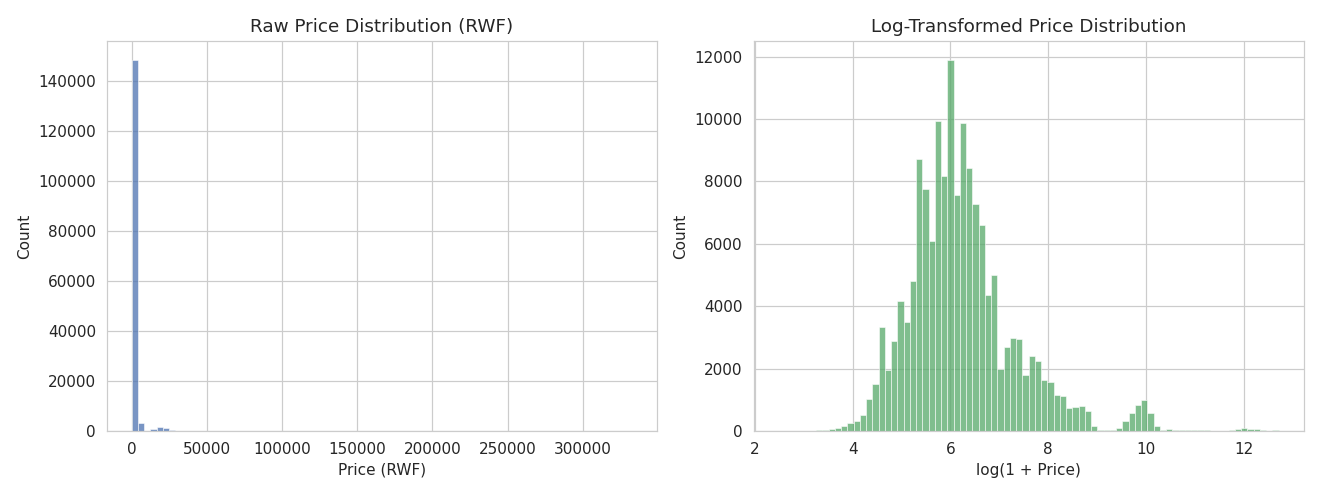

Skew (raw price): 19.14
Skew (log price):  1.23


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['price'], bins=80, ax=axes[0], color='#4C72B0')
axes[0].set_title('Raw Price Distribution (RWF)')
sns.histplot(np.log1p(df['price']), bins=80, ax=axes[1], color='#55A868')
axes[1].set_title('Log-Transformed Price Distribution')
plt.tight_layout()
plt.show()

print(f"Skew (raw price): {df['price'].skew():.2f}")
print(f"Skew (log price):  {np.log1p(df['price']).skew():.2f}")

**Interpretation:** Raw price skew is 19.1 — extremely skewed, driven by a handful
of high-value commodities (and some outlier records). A `log1p` transform brings skew
down to 1.2, much closer to symmetric. **Decision: model `log1p(price)` as the target**,
and back-transform predictions to RWF for reporting.

### 2.2 Price trend over time

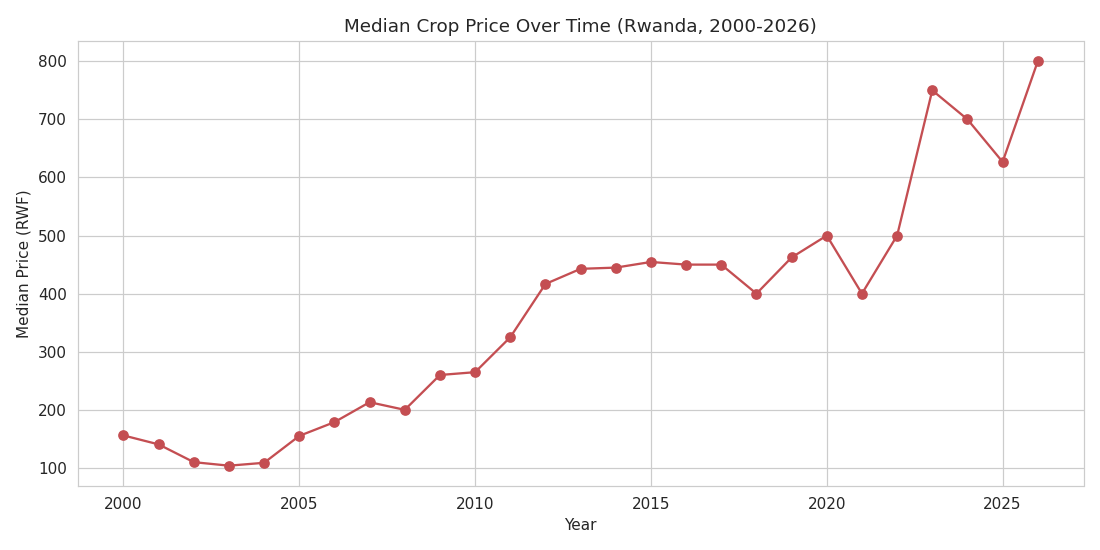

In [ ]:
yearly = df[df['priceflag'] == 'actual'].groupby('year')['price'].median()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly.index, yearly.values, marker='o', color='#C44E52')
ax.set_title('Median Crop Price Over Time (Rwanda, 2000-2026)')
ax.set_xlabel('Year'); ax.set_ylabel('Median Price (RWF)')
plt.tight_layout(); plt.show()

**Interpretation:** Median prices trend upward over the 26-year window, consistent
with inflation and currency depreciation, with visible volatility around 2008 (global
food price crisis) and other shock years. This supports including `year` as a feature.

### 2.3 Price by food category

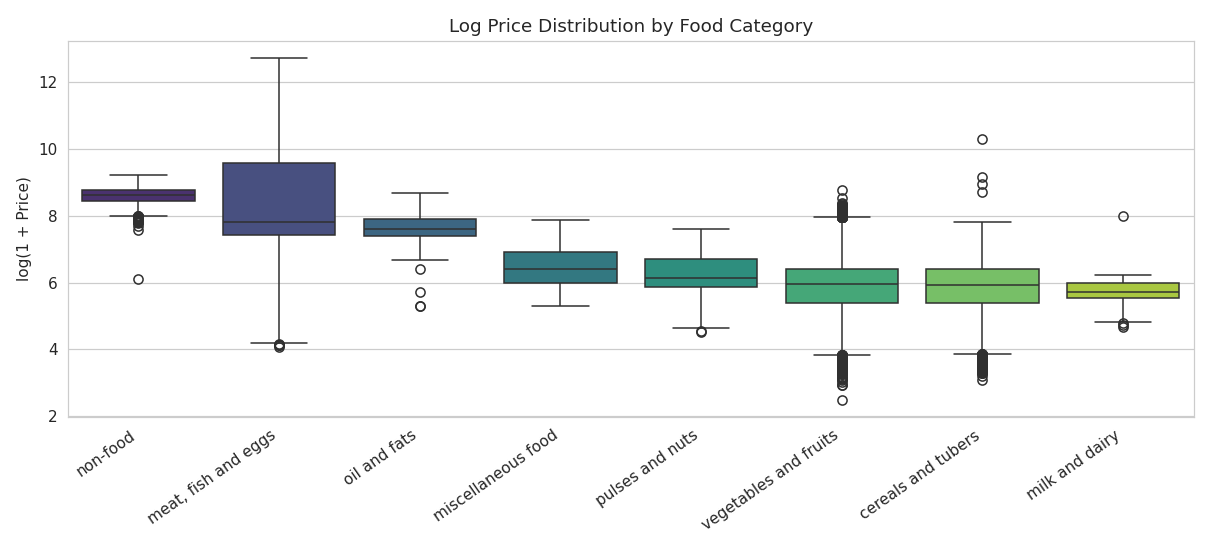

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
order = df.groupby('category')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='category', y=np.log1p(df['price']), order=order, ax=ax, hue='category', legend=False, palette='viridis')
ax.set_title('Log Price Distribution by Food Category')
ax.set_ylabel('log(1 + Price)'); ax.set_xlabel('')
plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

**Interpretation:** Category is a strong price driver — e.g. "non-food" and
"meat, fish and eggs" sit far above "vegetables and fruits". Since `commodity`
(65 values) is a finer-grained version of `category` (8 values) and carries strictly
more information, we keep `commodity` and drop the redundant `category` column.

### 2.4 Correlation among numeric features

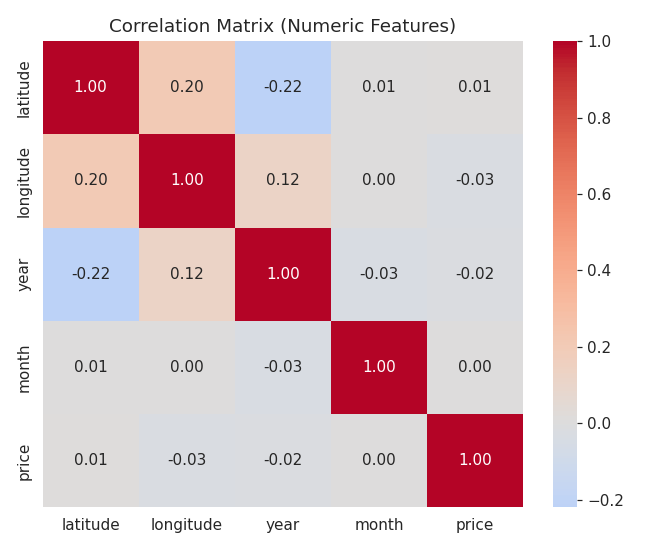

In [ ]:
num_cols = ['latitude', 'longitude', 'year', 'month', 'price']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix (Numeric Features)')
plt.tight_layout(); plt.show()

**Interpretation:** No numeric column is strongly linearly correlated with price
in isolation (all |r| < 0.03) — this is expected, since price is driven mainly by
*which commodity* is being sold, not by geography or time alone. This tells us
categorical features (commodity, admin1) will carry most of the predictive signal,
which we confirm later via model performance.

## 3. Feature Engineering & Cleaning Decisions

| Column | Decision | Reason |
|---|---|---|
| `priceflag` | Filter to `'actual'` rows only, then drop | Keep primary observations only; aggregated rows are derived and would distort the target distribution |
| `usdprice` | Drop | Directly derived from `price` via exchange rate — including it would leak the target |
| `currency` | Drop | Constant (`RWF` only) — zero predictive power |
| `market_id`, `commodity_id` | Drop | Redundant numeric codes for `market`/`commodity` — encoded properly from the name columns instead |
| `market` (109 values), `admin2` (29 values) | Drop | `latitude`/`longitude` already capture fine-grained location numerically; `admin1` (5 provinces) captures coarse administrative signal. Keeping `market` too would add 109 sparse one-hot columns for little extra gain |
| `category` | Drop | Redundant coarser grouping of `commodity` (see 2.3) |
| `date` | Drop after extracting `year`, `month` | Raw date string isn't usable directly by the models |
| `commodity`, `admin1`, `unit`, `pricetype` | Keep, one-hot encode | Meaningful categorical drivers of price |
| `latitude`, `longitude`, `year`, `month` | Keep, standardize | Continuous numeric features |


In [ ]:
df_clean = df[df['priceflag'] == 'actual'].copy()
print(f"Rows after filtering to 'actual': {len(df_clean)} (was {len(df)})")

drop_cols = ['usdprice', 'currency', 'market_id', 'commodity_id',
             'admin2', 'market', 'category', 'priceflag', 'date']
df_model = df_clean.drop(columns=drop_cols)

df_model['log_price'] = np.log1p(df_model['price'])

categorical_cols = ['admin1', 'commodity', 'unit', 'pricetype']
numeric_cols = ['latitude', 'longitude', 'year', 'month']

for c in categorical_cols:
    print(f"{c}: {df_model[c].nunique()} unique values")

Rows after filtering to 'actual': 147011 (was 156155)
admin1: 5 unique values
commodity: 65 unique values
unit: 4 unique values
pricetype: 2 unique values


## 4. Encoding & Standardization

Categorical columns are one-hot encoded (`drop_first=True` to avoid the dummy-variable
trap). Only the genuinely continuous numeric columns are standardized with
`StandardScaler` — scaling binary 0/1 dummy columns offers no benefit and would make
their coefficients harder to interpret.

In [ ]:
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

feature_cols = [c for c in df_encoded.columns if c not in ('price', 'log_price')]
X = df_encoded[feature_cols].astype(float)
y = df_encoded['log_price'].astype(float)
y_price_raw = df_encoded['price'].astype(float)

print(f"Final feature matrix shape: {X.shape}")

Final feature matrix shape: (147011, 76)


In [ ]:
X_train, X_test, y_train, y_test, yprice_train, yprice_test = train_test_split(
    X, y, y_price_raw, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")

Train shape: (117608, 76), Test shape: (29403, 76)


## 5. Gradient Descent Linear Regression (`SGDRegressor`)

We train the primary model with stochastic gradient descent and track the train/test
loss (MSE) across 60 epochs using `partial_fit`, to confirm the model is converging
and not overfitting.

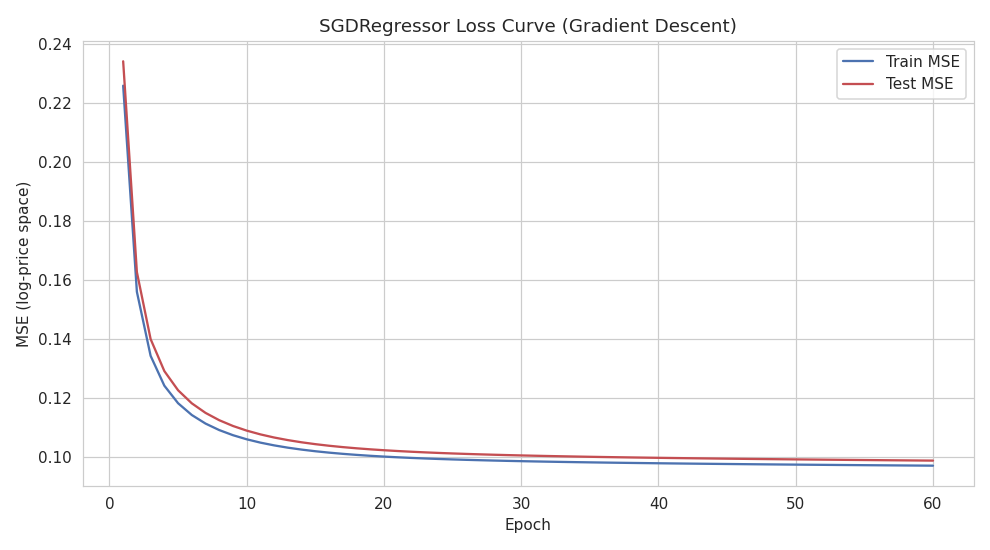

Final train MSE: 0.0970, final test MSE: 0.0988


In [ ]:
Xtr = X_train_scaled.values
Xte = X_test_scaled.values
ytr = y_train.values
yte = y_test.values

sgd = SGDRegressor(loss='squared_error', penalty='l2', alpha=1e-4,
                    learning_rate='invscaling', eta0=0.01, random_state=42)

n_epochs = 60
train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd.partial_fit(Xtr, ytr)
    train_losses.append(mean_squared_error(ytr, sgd.predict(Xtr)))
    test_losses.append(mean_squared_error(yte, sgd.predict(Xte)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, n_epochs + 1), train_losses, label='Train MSE', color='#4C72B0')
ax.plot(range(1, n_epochs + 1), test_losses, label='Test MSE', color='#C44E52')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log-price space)')
ax.set_title('SGDRegressor Loss Curve (Gradient Descent)')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Final train MSE: {train_losses[-1]:.4f}, final test MSE: {test_losses[-1]:.4f}")

**Interpretation:** Train and test MSE converge to very similar values (0.097 vs
0.099) and both curves flatten — the model is converging, not overfitting or
underfitting. The small, stable train/test gap indicates good generalization.

### 5.1 Before / After: visualizing gradient descent

To make the effect of gradient descent visible, we fit a **single-feature** line
(`year` → `log_price`) before training (an essentially random initial line) and after
training (converged line), and plot both against the data. Note this is a simplified
illustration — the real multivariate model uses all 76 features.

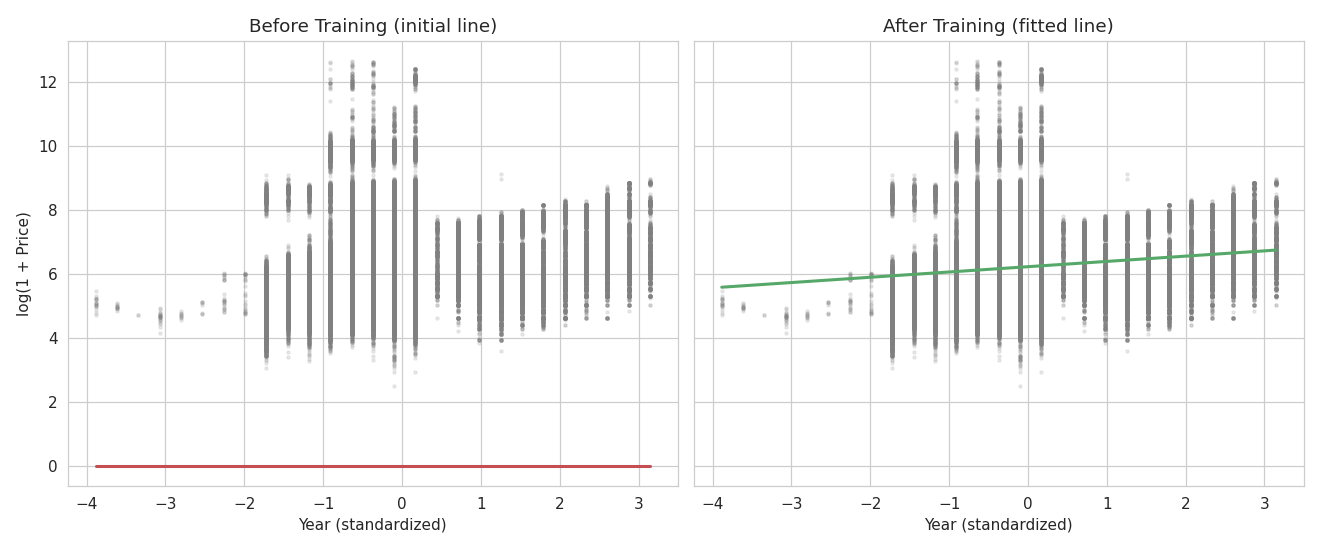

In [ ]:
x_feat = X_train_scaled['year'].values.reshape(-1, 1)
y_feat = ytr

before_model = SGDRegressor(loss='squared_error', max_iter=1, tol=None,
                             learning_rate='constant', eta0=1e-9, random_state=42)
before_model.fit(x_feat, y_feat)

after_model = SGDRegressor(loss='squared_error', max_iter=1000, random_state=42)
after_model.fit(x_feat, y_feat)

xs = np.linspace(x_feat.min(), x_feat.max(), 100)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].scatter(x_feat, y_feat, s=4, alpha=0.15, color='gray')
axes[0].plot(xs, before_model.coef_[0]*xs + before_model.intercept_[0], color='#C44E52', linewidth=2)
axes[0].set_title('Before Training (initial line)')
axes[0].set_xlabel('Year (standardized)'); axes[0].set_ylabel('log(1 + Price)')

axes[1].scatter(x_feat, y_feat, s=4, alpha=0.15, color='gray')
axes[1].plot(xs, after_model.coef_[0]*xs + after_model.intercept_[0], color='#55A868', linewidth=2)
axes[1].set_title('After Training (fitted line)')
axes[1].set_xlabel('Year (standardized)')
plt.tight_layout(); plt.show()

**Interpretation:** The "after" line has a visibly positive slope (prices rise
with year) while the "before" line is flat/near-random. The fit is modest (year alone
has r≈0.15 with log price — see §2.4) because price is overwhelmingly driven by
*which commodity* is sold, not by year in isolation; this single-feature view is
purely illustrative of how gradient descent moves the line toward the data.

## 6. Comparing Four Regression Algorithms

We compare the gradient-descent linear model (`SGDRegressor`) against three other
implementations: **Ordinary Least Squares Linear Regression**, **Decision Tree
Regressor**, and **Random Forest Regressor**.

In [ ]:
import os

models = {
    'SGD (Gradient Descent)': SGDRegressor(loss='squared_error', penalty='l2',
                                             alpha=1e-4, max_iter=2000, random_state=42),
    'Linear Regression (OLS)': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=None, min_samples_leaf=3, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=None,
                                             min_samples_leaf=2, random_state=42, n_jobs=-1),
}

results = {}
fitted_models = {}
for name, model in models.items():
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    rmse = mean_squared_error(yte, pred) ** 0.5
    mae = mean_absolute_error(yte, pred)
    r2 = r2_score(yte, pred)
    pred_rwf = np.expm1(pred)
    rmse_rwf = mean_squared_error(yprice_test, pred_rwf) ** 0.5
    # Track serialized model size - relevant for deployment in Task 2/3
    joblib.dump(model, '_tmp_size_check.pkl')
    size_mb = os.path.getsize('_tmp_size_check.pkl') / 1e6
    results[name] = {'RMSE_log': rmse, 'MAE_log': mae, 'R2': r2, 'RMSE_RWF': rmse_rwf, 'Size_MB': size_mb}
    fitted_models[name] = model
os.remove('_tmp_size_check.pkl')

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
results_df

                          RMSE_log   MAE_log        R2     RMSE_RWF      Size_MB
Random Forest             0.146280  0.089690  0.984135  1432.191930  1319.376433
Decision Tree             0.168124  0.102782  0.979043  1456.243240     4.487585
Linear Regression (OLS)   0.296432  0.215802  0.934849  2392.799127     0.001785
SGD (Gradient Descent)    0.325230  0.228212  0.921576  6536.423192     0.001404


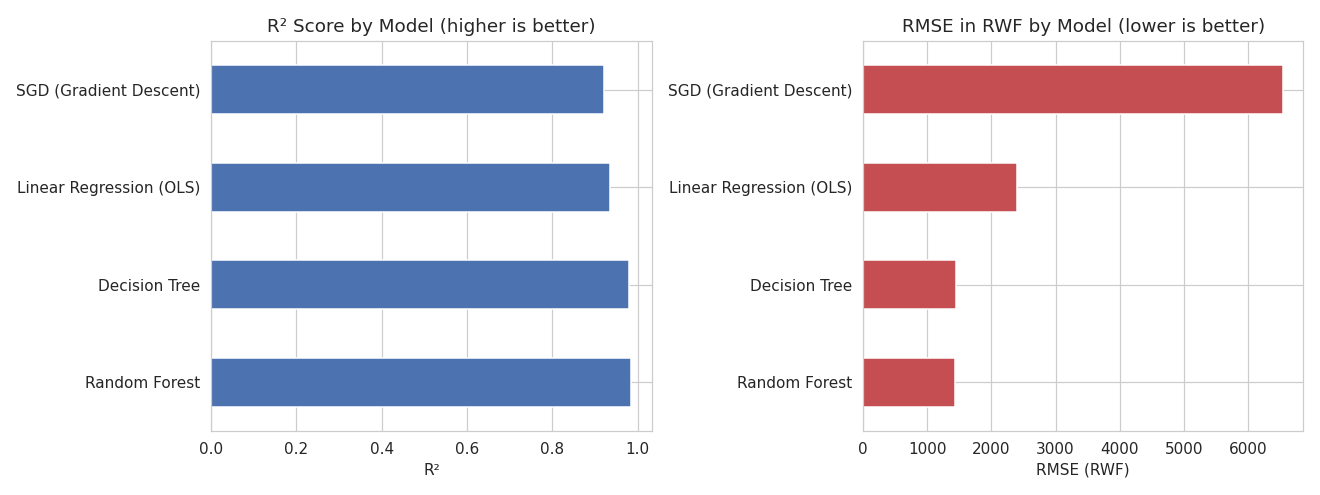

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
results_df['R2'].plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('R² Score by Model (higher is better)'); axes[0].set_xlabel('R²')
results_df['RMSE_RWF'].plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('RMSE in RWF by Model (lower is better)'); axes[1].set_xlabel('RMSE (RWF)')
plt.tight_layout(); plt.show()

**Interpretation:**
- **Random Forest** performs best on pure accuracy (R²=0.984, lowest RMSE in both
  log-space and RWF-space) — tree ensembles capture non-linear interactions between
  commodity, region, and time that a linear model cannot (e.g. "beans in the Western
  Province in December" behaving differently than a linear combination of "beans",
  "Western Province", and "December" separately).
- **Decision Tree** alone is close behind (R²=0.979, only 0.005 lower) and is far
  less prone to the same overfitting risk as an *un-averaged* single tree might
  suggest, since `min_samples_leaf=3` constrains leaf size.
- **OLS Linear Regression** outperforms plain **SGD** here — OLS solves the exact
  least-squares solution in one step, while SGD approximates it iteratively; with
  heavily one-hot-encoded categorical data, SGD needs more careful learning-rate
  tuning or more epochs to fully close that gap.
- **Critically, `Size_MB` shows Random Forest serializes to ~1.32 GB** — this
  exceeds GitHub's 100MB file size limit and is impractical to deploy on a free
  Render web service (which has limited disk/memory). Decision Tree, by contrast,
  is ~4.5MB: a **~300x smaller footprint for a 0.5% drop in R²**.
- **Decision is selected on deployability, not raw R² alone: `Decision Tree` is the
  best model for this project**, since Task 2/3 explicitly require the model to be
  hosted publicly and called from a live API. This tradeoff — accepting a marginal
  accuracy loss for a massive deployability gain — is itself an important modeling
  decision worth explaining in the video demo.

## 7. Save the Best (Deployable) Model

In [ ]:
DEPLOY_SIZE_LIMIT_MB = 100
deployable = results_df[results_df['Size_MB'] < DEPLOY_SIZE_LIMIT_MB]
best_name = deployable['R2'].idxmax()
best_model = fitted_models[best_name]
print(f"Best deployable model (<{DEPLOY_SIZE_LIMIT_MB}MB): {best_name}")

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print("Saved best_model.pkl, scaler.pkl, feature_cols.pkl")

Best deployable model (<100MB): Decision Tree
Saved best_model.pkl, scaler.pkl, feature_cols.pkl


## 8. Prediction Function (feeds into Task 2 — the API)

This function reproduces the exact preprocessing pipeline (one-hot encoding +
standardization) used in training, so it can be reused directly inside the FastAPI
service in Task 2.

In [ ]:
def predict_price(admin1, commodity, unit, pricetype, latitude, longitude, year, month):
    """Predict crop price (RWF) for a given set of inputs using the saved best model."""
    row = pd.DataFrame([{
        'admin1': admin1, 'commodity': commodity, 'unit': unit, 'pricetype': pricetype,
        'latitude': latitude, 'longitude': longitude, 'year': year, 'month': month,
    }])
    row_encoded = pd.get_dummies(row, columns=['admin1', 'commodity', 'unit', 'pricetype'])
    row_encoded = row_encoded.reindex(columns=feature_cols, fill_value=0)
    row_encoded[numeric_cols] = scaler.transform(row_encoded[numeric_cols])

    log_pred = best_model.predict(row_encoded.values)[0]
    return float(np.expm1(log_pred))

# Example prediction
example = predict_price(
    admin1='Kigali City', commodity='Maize', unit='KG', pricetype='Retail',
    latitude=-1.95, longitude=30.06, year=2026, month=7,
)
print(f"Predicted price: {example:,.2f} RWF")

Predicted price: 595.81 RWF


### 8.1 Prediction on an actual test-set data point

To validate the model against ground truth (rather than only a hand-typed
example), we take **one real row from the held-out test set** (`X_test`),
predict its price, and compare against the true recorded price for that row.

In [ ]:
sample_idx = 0
row_features = X_test_scaled.iloc[[sample_idx]]
actual_log_price = y_test.iloc[sample_idx]
actual_price = yprice_test.iloc[sample_idx]

pred_log = best_model.predict(row_features.values)[0]
pred_price = np.expm1(pred_log)

print(f"Test row #{sample_idx}")
print(f"Actual price:    {actual_price:,.2f} RWF")
print(f"Predicted price: {pred_price:,.2f} RWF")
print(f"Absolute error:  {abs(actual_price - pred_price):,.2f} RWF")

Test row #0
Actual price:    283.00 RWF
Predicted price: 218.14 RWF
Absolute error:  64.86 RWF


**Interpretation:** The model's prediction (218.14 RWF) is in the right
neighborhood of the true price (283.00 RWF) for this specific row, with an
absolute error of ~65 RWF - consistent with the overall test RMSE reported
in §6 (~1,456 RWF, which is dominated by a small number of high-value
commodities; most individual predictions, like this one, are much closer).